In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
salary_data = pd.read_csv('Salary_Data.csv')

In [4]:
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [6]:
salary_data.shape

(30, 2)

In [7]:
salary_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [8]:
salary_data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [10]:
salary_data.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [11]:
salary_data.skew()

YearsExperience    0.37956
Salary             0.35412
dtype: float64

In [14]:
salary_data.kurt()

YearsExperience   -1.012212
Salary            -1.295421
dtype: float64

In [15]:
salary_data[['YearsExperience','Salary']].cov()

,YearsExperience,Salary
YearsExperience,8.053609,7.610630e+04
Salary,76106.303448,7.515510e+08


In [17]:
salary_data.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


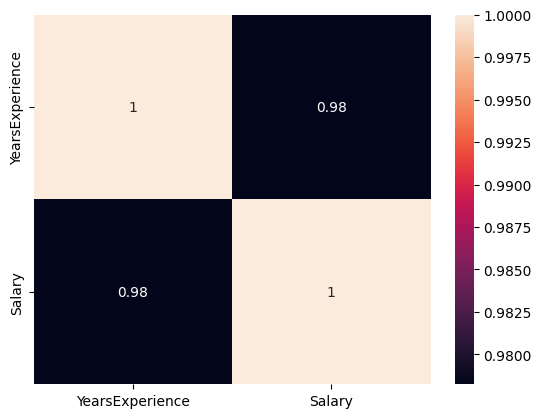

In [18]:
sns.heatmap(salary_data.corr(),annot=True)
plt.show()

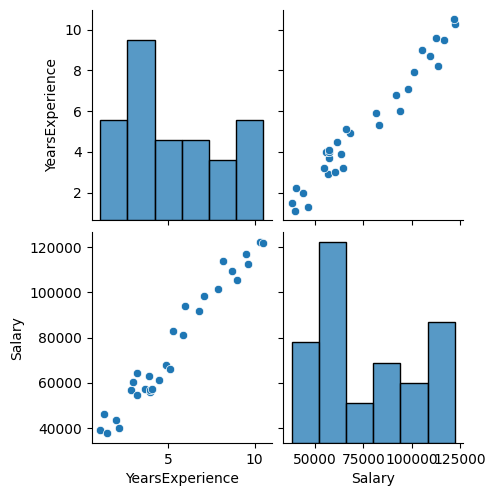

In [19]:
sns.pairplot(salary_data)
plt.show()

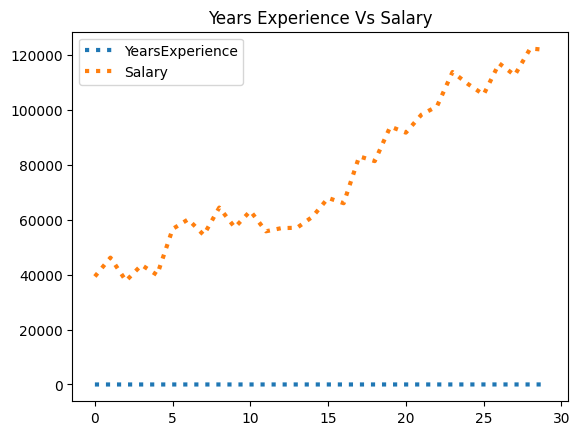

In [20]:
salary_data.plot.line(linestyle=':', linewidth='3')
plt.title('Years Experience Vs Salary')
plt.show()

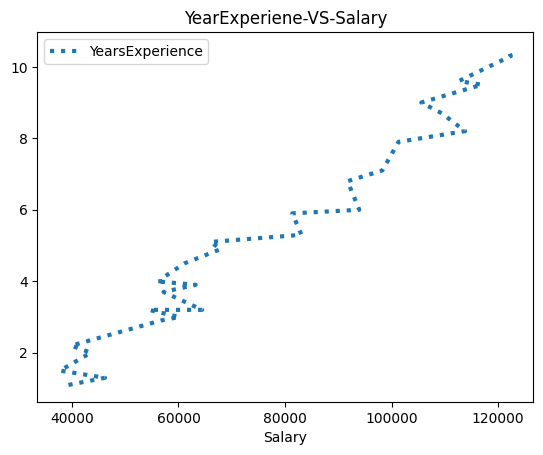

In [21]:
salary_data = pd.DataFrame(salary_data)
salary_data.plot.line(x='Salary', linestyle=':', linewidth='3')
plt.title('YearExperiene-VS-Salary')
plt.show()

In [22]:
X = salary_data.drop('Salary', axis = 1)
y = salary_data.Salary

In [23]:
X.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [24]:
y.head()

0    39343
1    46205
2    37731
3    43525
4    39891
Name: Salary, dtype: int64

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.3)

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
LR = LinearRegression()

In [29]:
LR.fit(X_train, y_train)

LinearRegression()

In [32]:
LR.intercept_

np.float64(26777.391341197625)

In [33]:
LR.coef_

array([9360.26128619])

In [34]:
y_pred = LR.predict(X_test)

In [35]:
y_pred

array([ 40817.78327049, 123188.08258899,  65154.46261459,  63282.41035735,
       115699.87356004, 108211.66453108, 116635.89968866,  64218.43648597,
        76386.77615802])

In [36]:
y_test

2      37731
28    122391
13     57081
10     63218
26    116969
24    109431
27    112635
11     55794
17     83088
Name: Salary, dtype: int64

In [38]:
from sklearn import metrics

In [39]:
R2 = metrics.r2_score(y_test, y_pred)

In [40]:
R2

0.9740993407213511

In [41]:
print(metrics.mean_absolute_error(y_test,y_pred))

3737.417861878896


In [42]:
print(metrics.mean_squared_error(y_test,y_pred))

23370078.800832972


In [43]:
print(np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

4834.260936361728


In [44]:
print(LR.predict([[5]])) 

[73578.69777217]


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [45]:
error= y_test-y_pred

In [46]:
error

2    -3086.783270
28    -797.082589
13   -8073.462615
10     -64.410357
26    1269.126440
24    1219.335469
27   -4000.899689
11   -8424.436486
17    6701.223842
Name: Salary, dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_9832\3292444513.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error)


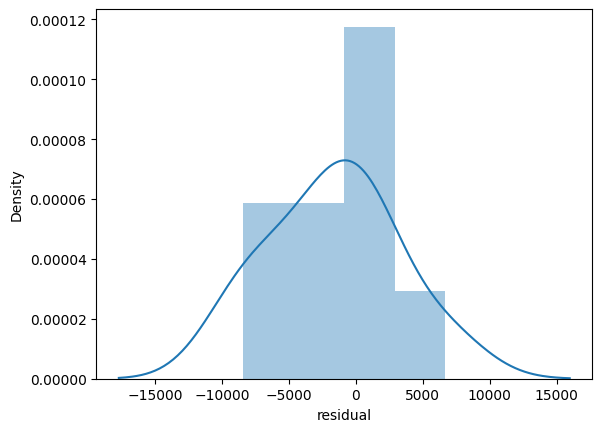

In [53]:
sns.distplot(error)
plt.xlabel('residual')
plt.show()

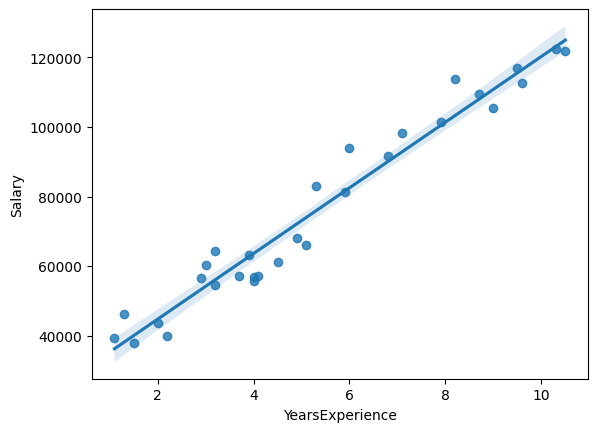

In [55]:
sns.regplot(x=X,y=y)
plt.show()